# Notebook que incluye interact

# Preprocesamiento

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score

from ipywidgets import interact, widgets


In [2]:
project_dir = Path().resolve().parent

model_path = os.path.join(project_dir, r"models\model_4C_3FC.h5")
data_path = os.path.join(project_dir, r"data\raw\sdss_dat_files")
labels_path = os.path.join(project_dir, r"data\raw\label_data")

print(project_dir)
print(model_path)
print(data_path)
print(labels_path)

C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF
C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\models\model_4C_3FC.h5
C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files
C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\label_data


In [3]:
def process_spectrum(file_path):
    try:
        sed = np.loadtxt(file_path, unpack=True)
        flux = sed[1, 48:-400]   # 4200 puntos

        # Ajuste a 3750 puntos, como espera la red
        if len(flux) > 3750:
            diff = len(flux) - 3750
            start = diff // 2
            flux = flux[start:start + 3750]
        elif len(flux) < 3750:
            flux = np.pad(flux, (0, 3750 - len(flux)), mode='constant')

        norm_val = flux[2100]
        if norm_val == 0 or np.isnan(norm_val):
            norm_val = np.mean(flux)

        if norm_val == 0 or np.isnan(norm_val):
            return None

        flux = flux / norm_val

        if np.isnan(flux).any():
            return None

        return flux.astype(np.float32)

    except Exception:
        return None

In [4]:
fields = ['File Name', 'MJD', 'Target ID', 'DB ID', 'Classification', 'Data Quality']
raw_labels_df = pd.DataFrame()

for filename in os.listdir(labels_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(labels_path, filename)
        df = pd.read_csv(file_path, usecols=fields)
        raw_labels_df = pd.concat([raw_labels_df, df], ignore_index=True)

print(raw_labels_df.shape)
print(raw_labels_df['Classification'].value_counts().head(20))

(35253, 6)
Classification
WDA        13748
STAR        8749
WD+MS       2555
DUNNO       2086
UNCLASS     1441
WDC         1353
WDB         1186
WDELM       1069
sdX          744
WD           743
WDZ          383
CV           356
EXGAL        301
WDH          272
WDO          184
WDQ           81
WELM           1
DA             1
Name: count, dtype: int64


In [5]:
file_dict = {}

for folder in os.listdir(data_path):
    folder_full_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_full_path):
        for filename in os.listdir(folder_full_path):
            if filename.endswith('.dat'):
                key = filename.split('-')[-2] + '_' + filename.split('_')[-1]
                file_dict[key] = os.path.join(folder, filename)

print(f"Archivos .dat indexados: {len(file_dict)}")

Archivos .dat indexados: 33698


In [6]:
full_model = load_model(model_path)

dummy_input = np.zeros((1, 3750, 1), dtype=np.float32)
_ = full_model.predict(dummy_input, verbose=0)

full_model.summary()

c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1874, 128)      │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 937, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 467, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 233, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 115, 32)        │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 57, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 27, 16)         │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 208)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        26,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,246 (317.37 KB)

 Trainable params: 81,244 (317.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Construir extractores de capas 

In [7]:
def build_extractor_until(layer_name, full_model):
    input_layer = layers.Input(shape=(3750, 1))
    x = input_layer

    for layer in full_model.layers:
        x = layer(x)
        if layer.name == layer_name:
            break

    extractor = Model(inputs=input_layer, outputs=x)
    return extractor

flatten_extractor = build_extractor_until("flatten", full_model)
dense_extractor   = build_extractor_until("dense", full_model)
dense1_extractor  = build_extractor_until("dense_1", full_model)
dense2_extractor  = build_extractor_until("dense_2", full_model)

print("extrat listos")

extrat listos


In [8]:
def build_class_dataframe(class_name):
    star_df = raw_labels_df[raw_labels_df['Classification'] == class_name].copy()

    spectrum_list = []
    for _, row in star_df.iterrows():
        filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
        if filekey in file_dict:
            spectrum_list.append({
                'filename': file_dict[filekey],
                'classID': row['Classification']
            })

    spectrum_df = pd.DataFrame(spectrum_list)
    return spectrum_df

In [9]:
# fc que carga espectros de una clase, los preprocesa y los deja listo para entrar a la NN
def load_class_spectra(class_name, n_samples=1100, random_state=42):
    spectrum_df = build_class_dataframe(class_name)
    print(f"{class_name}: disponibles con match a .dat = {len(spectrum_df)}")

    if len(spectrum_df) < n_samples:
        raise ValueError(f"No hay suficientes espectros para {class_name}. Disponibles: {len(spectrum_df)}")

    selected_df = spectrum_df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    X_list = []
    valid_rows = []

    for _, row in selected_df.iterrows():
        f_path = os.path.join(data_path, row['filename'])
        spec = process_spectrum(f_path)
        if spec is not None:
            X_list.append(spec)
            valid_rows.append(row)

    X_final = np.array(X_list, dtype=np.float32)
    X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"{class_name}: espectros válidos finales = {X_input.shape[0]}")
    return X_input, valid_df

In [10]:
# fc que carga los espectros y los conserva en formado 2D para poder graficarlos después
# retorna X_final, que son los espectros originales preprocesados, listos para graficiar
def load_class_spectra_DRACULA(class_name, n_samples=1100, random_state=42):
    spectrum_df = build_class_dataframe(class_name)
    print(f"{class_name}: disponibles con match a .dat = {len(spectrum_df)}")

    if len(spectrum_df) < n_samples:
        raise ValueError(f"No hay suficientes espectros para {class_name}. Disponibles: {len(spectrum_df)}")

    selected_df = spectrum_df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    X_list = []
    valid_rows = []

    for _, row in selected_df.iterrows():
        f_path = os.path.join(data_path, row['filename'])
        spec = process_spectrum(f_path)
        if spec is not None:
            X_list.append(spec)
            valid_rows.append(row)

    X_final = np.array(X_list, dtype=np.float32)
    X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"{class_name}: espectros válidos finales = {X_input.shape[0]}")
    return X_final, X_input, valid_df

In [11]:
# fc que carga espectros, conserva el flujo (eje y) normalizado y conserva el eje real de longitud de onda
def load_class_spectra_DRACULA_with_wavelength(class_name, n_samples=1100, random_state=42):
    spectrum_df = build_class_dataframe(class_name)
    print(f"{class_name}: disponibles con match a .dat = {len(spectrum_df)}")

    if len(spectrum_df) < n_samples:
        raise ValueError(f"No hay suficientes espectros para {class_name}. Disponibles: {len(spectrum_df)}")

    selected_df = spectrum_df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    wave_list = []
    flux_list = []
    valid_rows = []

    for _, row in selected_df.iterrows():
        f_path = os.path.join(data_path, row['filename'])

        wave, flux = process_spectrum_with_wavelength(f_path)

        if wave is not None and flux is not None:
            wave_list.append(wave)
            flux_list.append(flux)
            valid_rows.append(row)

    W_final = np.array(wave_list, dtype=np.float32)
    X_final = np.array(flux_list, dtype=np.float32)

    X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"{class_name}: espectros válidos finales = {X_input.shape[0]}")
    print(f"{class_name}: shape wavelength = {W_final.shape}")
    print(f"{class_name}: shape flux = {X_final.shape}")

    return W_final, X_final, X_input, valid_df

'''
Uso de esta fc -> mostrar un espectro / muestra
W_wda, X_wda_spec, X_wda_input, df_wda_DRAC = load_class_spectra_DRACULA_with_wavelength(
    "WDA",
    n_samples=1100,
    random_state=42
)

sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(W_wda[sample_idx], X_wda_spec[sample_idx])
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized flux")
plt.title(f"WDA - sample {sample_idx}")
plt.tight_layout()
plt.show()
''' 

'''
Uso de esta fc -> mostrar el promedio + lo anterior
mean_wave = np.nanmean(W_wda, axis=0)
mean_flux = np.nanmean(X_wda_spec, axis=0)

plt.figure(figsize=(10, 5))
plt.plot(mean_wave, mean_flux, label="Total mean spectrum")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized flux")
plt.title("WDA - Total mean spectrum")
plt.legend()
plt.tight_layout()
plt.show()
'''

'\nUso de esta fc -> mostrar el promedio + lo anterior\nmean_wave = np.nanmean(W_wda, axis=0)\nmean_flux = np.nanmean(X_wda_spec, axis=0)\n\nplt.figure(figsize=(10, 5))\nplt.plot(mean_wave, mean_flux, label="Total mean spectrum")\nplt.xlabel("Wavelength [Å]")\nplt.ylabel("Normalized flux")\nplt.title("WDA - Total mean spectrum")\nplt.legend()\nplt.tight_layout()\nplt.show()\n'

In [12]:
def extract_layer_features(X_input): # fc que extrae representaciones internas de la red
    flatten_features = flatten_extractor.predict(X_input, batch_size=64, verbose=1)
    dense_features   = dense_extractor.predict(X_input, batch_size=64, verbose=1)
    dense1_features  = dense1_extractor.predict(X_input, batch_size=64, verbose=1)
    dense2_features  = dense2_extractor.predict(X_input, batch_size=64, verbose=1)

    print("flatten:", flatten_features.shape)
    print("dense:", dense_features.shape)
    print("dense_1:", dense1_features.shape)
    print("dense_2:", dense2_features.shape)

    return flatten_features, dense_features, dense1_features, dense2_features

In [13]:
def reduce_all_to_32(flatten_features, dense_features, dense1_features, dense2_features): # fc que reduce a 32d
    flatten_32 = PCA(n_components=32, random_state=42).fit_transform(flatten_features)
    dense_32   = PCA(n_components=32, random_state=42).fit_transform(dense_features)
    dense1_32  = PCA(n_components=32, random_state=42).fit_transform(dense1_features)
    dense2_32  = dense2_features.copy()  # ya está en 32

    print("flatten_32:", flatten_32.shape)
    print("dense_32:", dense_32.shape)
    print("dense1_32:", dense1_32.shape)
    print("dense2_32:", dense2_32.shape)

    return {
        "flatten": flatten_32,
        "dense": dense_32,
        "dense_1": dense1_32,
        "dense_2": dense2_32
    }

# Funciones para graficar 

In [14]:
# fc que grafica los features_nd en 2D
def plot_internal_structure_2d(
    features_nd,
    class_name,
    layer_name,
    method="pca",
    xlim=None,
    ylim=None,
    kpca_kernel="rbf",
    kpca_gamma=None,
    kpca_degree=3,
    kpca_coef0=1,
    scale_before_pca=False,
    scale_before_tsne=False,
    scale_before_kpca=True
):
    method = method.lower()

    if method == "pca":
        X_plotPCA = features_nd.copy()

        if scale_before_pca:
            X_plotPCA = StandardScaler().fit_transform(X_plotPCA)

        emb_2d = PCA(n_components=2, random_state=42).fit_transform(X_plotPCA)

    elif method == "tsne":
        X_plotTSNE = features_nd.copy()

        if scale_before_tsne:
            X_plotTSNE = StandardScaler().fit_transform(X_plotTSNE)

        emb_2d = TSNE(
            n_components=2,
            random_state=42,
            perplexity=30,
            init='pca'
        ).fit_transform(X_plotTSNE)

    elif method == "kpca":
        X_kpca = features_nd.copy()

        if scale_before_kpca:
            X_kpca = StandardScaler().fit_transform(X_kpca)

        emb_2d = KernelPCA(
            n_components=2,
            kernel=kpca_kernel,
            gamma=kpca_gamma,
            degree=kpca_degree,
            coef0=kpca_coef0
        ).fit_transform(X_kpca)

    else:
        raise ValueError("method debe ser 'pca', 'tsne' o 'kpca'")

    plt.figure(figsize=(6, 5))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=10, alpha=0.65)

    if method == "kpca":
        extra = " + scaled" if scale_before_kpca else ""
        n_samples = features_nd.shape[0]
        plt.title(f"{class_name} - {layer_name} - estructura interna (KPCA-{kpca_kernel}{extra}, n={n_samples})")

    elif method == "pca":
        extra = " + scaled" if scale_before_pca else ""
        n_samples = features_nd.shape[0]
        plt.title(f"{class_name} - {layer_name} - estructura interna (PCA{extra}, n={n_samples})")

    elif method == "tsne":
        extra = " + scaled" if scale_before_tsne else ""
        n_samples = features_nd.shape[0]
        plt.title(f"{class_name} - {layer_name} - estructura interna (TSNE{extra}, n={n_samples})")

    plt.xlabel("Comp. 1")
    plt.ylabel("Comp. 2")

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.show()

In [15]:
def plot_cluster_spectra(
    layer_name,
    method_name,
    class_name="WDA",
    spectra_2d=None,
    wavelength_2d=None,
    cluster_labels_dict=None,
    figsize=(14, 7),
):
    """
    Genera un gráfico interactivo con:
      - Espectro promedio de cada grupo (cluster) obtenido por el método de clustering.
      - Espectro promedio general de la clase (línea punteada negra).
      - Líneas de Balmer verticales (Halpha, Hbeta, Hgamma, Hdelta).

    Parámetros
    ----------
    layer_name : str
        Nombre de la capa de la red ("flatten", "dense", "dense_1", "dense_2").
    method_name : str
        Método de clustering ("kmeans", "spectral", "dbscan").
    class_name : str
        Nombre de la clase estelar (p.ej. "WDA").
    spectra_2d : np.ndarray
        Matriz de espectros originales, shape (n_samples, n_wavelengths).
    wavelength_2d : np.ndarray o None
        Matriz de longitudes de onda, shape (n_samples, n_wavelengths).
        Si None, se usa el índice espectral como eje X.
    cluster_labels_dict : dict
        Diccionario cluster_labels_all[class_name].
        Estructura: {layer_name: {method_name: labels_array}}.
    figsize : tuple
        Tamaño de la figura.

    Retorna
    -------
    matplotlib Figure
    """
    # --- Validaciones ---
    if spectra_2d is None:
        raise ValueError("Debe proporcionar spectra_2d (matriz 2D de espectros).")
    if cluster_labels_dict is None:
        raise ValueError("Debe proporcionar cluster_labels_dict.")

    spectra_2d = np.asarray(spectra_2d)

    if layer_name not in cluster_labels_dict:
        print(f"Capa '{layer_name}' no encontrada en cluster_labels_dict.")
        return
    if method_name not in cluster_labels_dict[layer_name]:
        print(f"Metodo '{method_name}' no encontrado para la capa '{layer_name}'.")
        return

    labels = np.asarray(cluster_labels_dict[layer_name][method_name])

    if len(labels) != spectra_2d.shape[0]:
        raise ValueError(
            f"labels ({len(labels)}) y spectra_2d ({spectra_2d.shape[0]}) no coinciden."
        )

    # --- Eje X ---
    if wavelength_2d is not None:
        wavelength_2d = np.asarray(wavelength_2d)
        x_axis = np.nanmean(wavelength_2d, axis=0)
        x_label = "Wavelength [Angstrom]"
        use_wavelength = True
    else:
        x_axis = np.arange(spectra_2d.shape[1])
        x_label = "Spectral index"
        use_wavelength = False

    # --- Lineas de Balmer (en Angstrom) ---
    balmer_lines = {
        "H-alpha":  6563,
        "H-beta":   4861,
        "H-gamma":  4341,
        "H-delta":  4102,
    }

    # --- Espectro promedio total de la clase ---
    mean_class = np.nanmean(spectra_2d, axis=0)

    # --- Clusters unicos ---
    unique_clusters = np.sort(np.unique(labels))

    # --- Paleta de colores ---
    n_clusters = len(unique_clusters)
    if n_clusters <= 10:
        cmap = plt.cm.get_cmap("tab10", n_clusters)
    else:
        cmap = plt.cm.get_cmap("tab20", n_clusters)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    for i, c in enumerate(unique_clusters):
        mask = labels == c
        n_in_cluster = int(mask.sum())
        cluster_spectra = spectra_2d[mask]
        mean_spec = np.nanmean(cluster_spectra, axis=0)

        if c == -1:
            label_text = f"Ruido / no asignado (n={n_in_cluster})"
            color = "gray"
        else:
            label_text = f"Cluster {c} (n={n_in_cluster})"
            color = cmap(i)

        ax.plot(x_axis, mean_spec, label=label_text, color=color, linewidth=1.5)

    # Espectro promedio de la clase
    ax.plot(
        x_axis,
        mean_class,
        label=f"Promedio {class_name} (n={spectra_2d.shape[0]})",
        color="black",
        linewidth=2.0,
        linestyle="--",
    )

    # Lineas de Balmer
    x_min, x_max = x_axis.min(), x_axis.max()
    for name, wl in balmer_lines.items():
        if use_wavelength and x_min <= wl <= x_max:
            ax.axvline(x=wl, color="red", linestyle=":", alpha=0.7, linewidth=1.0)
            ax.text(
                wl, ax.get_ylim()[1] * 0.97, name,
                color="red", fontsize=9, ha="center", va="top",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="red", alpha=0.8),
            )

    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Normalized flux", fontsize=12)
    ax.set_title(
        f"{class_name} -- Capa: {layer_name} -- Metodo: {method_name}",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    return fig


In [16]:
# funcion para graficar el espectro promedio total
def plot_total_mean_spectrum(
    spectra_2d,
    title="Total mean spectrum",
    wavelength=None,
    figsize=(10, 5),
    save_path=None
):
    """
    Grafica el espectro promedio total de todas las muestras.

    Parameters
    ----------
    spectra_2d : np.ndarray
        Matriz shape (n_samples, n_wavelengths)
    title : str
        Título del gráfico
    wavelength : np.ndarray or None
        Eje x. Si None, usa índice espectral
    figsize : tuple
    save_path : str or None
        Si se entrega, guarda la figura
    """

    spectra_2d = np.asarray(spectra_2d)

    if spectra_2d.ndim != 2:
        raise ValueError(f"spectra_2d debe ser 2D. Shape actual: {spectra_2d.shape}")

    mean_spec = spectra_2d.mean(axis=0)

    if wavelength is None:
        wavelength = np.arange(spectra_2d.shape[1])

    plt.figure(figsize=figsize)
    plt.plot(wavelength, mean_spec, label="Total mean spectrum")
    plt.xlabel("Spectral index")
    plt.ylabel("Normalized flux")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [17]:
# función para graficar una muestra individual 
def plot_single_spectrum(
    spectra_2d,
    sample_idx,
    valid_df=None,
    title=None,
    wavelength=None,
    figsize=(10, 5),
    save_path=None
):
    """
    Grafica un espectro individual a partir de su índice.

    Parameters
    ----------
    spectra_2d : np.ndarray
        Matriz shape (n_samples, n_wavelengths)
    sample_idx : int
        Índice de la muestra a graficar
    valid_df : pd.DataFrame or None
        Metadata opcional para mostrar info adicional en el título
    title : str or None
        Si None, construye uno automático
    wavelength : np.ndarray or None
        Eje x. Si None, usa índice espectral
    figsize : tuple
    save_path : str or None
        Si se entrega, guarda la figura
    """

    spectra_2d = np.asarray(spectra_2d)

    if spectra_2d.ndim != 2:
        raise ValueError(f"spectra_2d debe ser 2D. Shape actual: {spectra_2d.shape}")

    if sample_idx < 0 or sample_idx >= spectra_2d.shape[0]:
        raise IndexError(f"sample_idx fuera de rango. Debe estar entre 0 y {spectra_2d.shape[0]-1}")

    spectrum = spectra_2d[sample_idx]

    if wavelength is None:
        wavelength = np.arange(spectra_2d.shape[1])

    if title is None:
        title = f"Single spectrum - sample {sample_idx}"

        if valid_df is not None and sample_idx < len(valid_df):
            row = valid_df.iloc[sample_idx]

            extra_parts = []
            if "filename" in row.index:
                extra_parts.append(f"file: {row['filename']}")
            if "classID" in row.index:
                extra_parts.append(f"class: {row['classID']}")

            if len(extra_parts) > 0:
                title += "\n" + " | ".join(extra_parts)

    plt.figure(figsize=figsize)
    plt.plot(wavelength, spectrum, label=f"Sample {sample_idx}")
    plt.xlabel("Spectral index")
    plt.ylabel("Normalized flux")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [18]:
def plot_multiple_spectra(
    spectra_2d,
    sample_indices,
    valid_df=None,
    title="Selected spectra",
    wavelength=None,
    figsize=(10, 5),
    alpha=0.9,
    save_path=None
):
    """
    Grafica varias muestras individuales en la misma figura.

    Parameters
    ----------
    spectra_2d : np.ndarray
        Matriz shape (n_samples, n_wavelengths)
    sample_indices : list or array-like
        Índices de las muestras a graficar
    valid_df : pd.DataFrame or None
    title : str
    wavelength : np.ndarray or None
    figsize : tuple
    alpha : float
    save_path : str or None
    """

    spectra_2d = np.asarray(spectra_2d)

    if spectra_2d.ndim != 2:
        raise ValueError(f"spectra_2d debe ser 2D. Shape actual: {spectra_2d.shape}")

    if wavelength is None:
        wavelength = np.arange(spectra_2d.shape[1])

    plt.figure(figsize=figsize)

    for idx in sample_indices:
        if idx < 0 or idx >= spectra_2d.shape[0]:
            raise IndexError(f"sample_idx {idx} fuera de rango.")

        label = f"sample {idx}"

        if valid_df is not None and idx < len(valid_df):
            row = valid_df.iloc[idx]
            if "filename" in row.index:
                label += f" | {row['filename']}"

        plt.plot(wavelength, spectra_2d[idx], alpha=alpha, label=label)

    plt.xlabel("Spectral index")
    plt.ylabel("Normalized flux")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [19]:
def plot_7_figures_wda_flatten_spectral(
    spectra_2d,
    labels,
    wavelength,
    class_name="WDA",
    layer_name="flatten",
    method_name="spectral",
    alpha_group=0.025,
    linewidth_group=0.6,
    linewidth_mean=2.2,
    figsize=(11, 5),
    mark_balmer=True,
    robust_ylim=True,
    group_percentiles=(1, 99),
    diff_percentiles=(1, 99)
):
    """
    Genera 7 figuras:

    1) espectros del grupo 0
    2) espectros del grupo 1
    3) espectros del grupo 2
    4) espectro promedio total
    5) promedio grupo 0 - promedio total
    6) promedio grupo 1 - promedio total
    7) promedio grupo 2 - promedio total

    Además:
    - marca líneas de Balmer
    - mejora la visualización de los grupos usando alpha bajo
    - dibuja el promedio del grupo encima de los espectros individuales
    - puede ajustar automáticamente el eje y usando percentiles

    Returns
    -------
    dict con:
        total_mean
        group_means
        unique_clusters
    """

    spectra_2d = np.asarray(spectra_2d)
    labels = np.asarray(labels)
    wavelength = np.asarray(wavelength)

    if spectra_2d.ndim != 2:
        raise ValueError(f"spectra_2d debe ser 2D. Shape actual: {spectra_2d.shape}")

    if labels.ndim != 1:
        raise ValueError(f"labels debe ser 1D. Shape actual: {labels.shape}")

    if len(labels) != spectra_2d.shape[0]:
        raise ValueError("El número de labels no coincide con el número de espectros.")

    if len(wavelength) != spectra_2d.shape[1]:
        raise ValueError("El eje wavelength no coincide con el largo de los espectros.")

    unique_clusters = np.sort(np.unique(labels))

    if len(unique_clusters) != 3:
        print(f"Advertencia: se esperaban 3 clusters, pero se encontraron {len(unique_clusters)}: {unique_clusters}")

    # ---------------------------------------------------------
    # Promedio total
    # ---------------------------------------------------------
    total_mean = np.mean(spectra_2d, axis=0)

    # ---------------------------------------------------------
    # Promedios por grupo
    # ---------------------------------------------------------
    group_means = {}

    for cluster_id in unique_clusters:
        group_spectra = spectra_2d[labels == cluster_id]
        group_means[int(cluster_id)] = np.mean(group_spectra, axis=0)

    # =========================================================
    # FIGURAS 1, 2, 3: espectros de cada grupo por separado
    # =========================================================
    for cluster_id in unique_clusters:
        group_spectra = spectra_2d[labels == cluster_id]
        group_mean = group_means[int(cluster_id)]

        fig, ax = plt.subplots(figsize=figsize)

        for spectrum in group_spectra:
            ax.plot(
                wavelength,
                spectrum,
                alpha=alpha_group,
                linewidth=linewidth_group
            )

        # promedio del grupo encima
        ax.plot(
            wavelength,
            group_mean,
            linewidth=linewidth_mean,
            label=f"Group {cluster_id} mean"
        )

        ax.set_xlabel("Wavelength [Å]")
        ax.set_ylabel("Normalized flux")
        ax.set_title(
            f"{class_name} - {layer_name} - {method_name}\n"
            f"Group {cluster_id} spectra (n={group_spectra.shape[0]})"
        )

        # Ajuste robusto del eje y para que no manden los outliers
        if robust_ylim:
            p_low, p_high = np.percentile(group_spectra, group_percentiles)
            margin = 0.08 * (p_high - p_low)
            ax.set_ylim(p_low - margin, p_high + margin)

        if mark_balmer:
            add_balmer_lines(ax)

        ax.legend()
        plt.tight_layout()
        plt.show()

    # =========================================================
    # FIGURA 4: espectro promedio total
    # =========================================================
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(
        wavelength,
        total_mean,
        linewidth=linewidth_mean,
        label="Total mean spectrum"
    )
    ax.set_xlabel("Wavelength [Å]")
    ax.set_ylabel("Normalized flux")
    ax.set_title(
        f"{class_name} - {layer_name} - {method_name}\n"
        f"Total mean spectrum"
    )

    if robust_ylim:
        p_low, p_high = np.percentile(total_mean, [1, 99])
        margin = 0.10 * (p_high - p_low)
        ax.set_ylim(p_low - margin, p_high + margin)

    if mark_balmer:
        add_balmer_lines(ax)

    ax.legend()
    plt.tight_layout()
    plt.show()

    # =========================================================
    # FIGURAS 5, 6, 7: resta (promedio grupo - promedio total)
    # =========================================================
    for cluster_id in unique_clusters:
        diff_spectrum = group_means[int(cluster_id)] - total_mean

        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(
            wavelength,
            diff_spectrum,
            linewidth=linewidth_mean,
            label=f"Group {cluster_id} mean - total mean"
        )
        ax.axhline(0.0, linestyle="--", linewidth=1.2)

        ax.set_xlabel("Wavelength [Å]")
        ax.set_ylabel("Δ Normalized flux")
        ax.set_title(
            f"{class_name} - {layer_name} - {method_name}\n"
            f"Difference spectrum: Group {cluster_id} mean - total mean"
        )

        if robust_ylim:
            p_low, p_high = np.percentile(diff_spectrum, diff_percentiles)
            margin = 0.15 * (p_high - p_low + 1e-8)
            ax.set_ylim(p_low - margin, p_high + margin)

        if mark_balmer:
            add_balmer_lines(ax)

        ax.legend()
        plt.tight_layout()
        plt.show()

    return {
        "total_mean": total_mean,
        "group_means": group_means,
        "unique_clusters": unique_clusters
    }

In [20]:
def plot_cluster_means_together_from_7fig_results(
    results_7fig,
    labels,
    wavelength,
    class_name="WDA",
    layer_name="flatten",
    method_name="spectral",
    include_total_mean=True,
    mark_balmer=True,
    robust_ylim=True,
    figsize=(11, 5)
):
    """
    Grafica en una sola figura los espectros promedio de los grupos.

    Compatible con el output de:
    plot_7_figures_wda_flatten_spectral()

    Parameters
    ----------
    results_7fig : dict
        Output de plot_7_figures_wda_flatten_spectral()
    labels : np.ndarray
        Labels de clustering
    wavelength : np.ndarray
        Eje de longitud de onda
    include_total_mean : bool
        Si True, también grafica el promedio total de todas las muestras
    mark_balmer : bool
        Si True, marca líneas de Balmer
    robust_ylim : bool
        Si True, ajusta eje Y con percentiles
    """

    labels = np.asarray(labels)
    wavelength = np.asarray(wavelength)

    group_means = results_7fig["group_means"]
    total_mean = results_7fig["total_mean"]
    unique_clusters = results_7fig["unique_clusters"]

    fig, ax = plt.subplots(figsize=figsize)

    curves_for_ylim = []

    # ---------------------------------------------------------
    # Graficar promedio de cada grupo
    # ---------------------------------------------------------
    for cluster_id in unique_clusters:
        cluster_id_int = int(cluster_id)
        mean_spectrum = group_means[cluster_id_int]
        n_samples = np.sum(labels == cluster_id)

        ax.plot(
            wavelength,
            mean_spectrum,
            linewidth=2.2,
            label=f"Group {cluster_id_int} mean (n={n_samples})"
        )

        curves_for_ylim.append(mean_spectrum)

    # ---------------------------------------------------------
    # Opcional: promedio total
    # ---------------------------------------------------------
    if include_total_mean:
        ax.plot(
            wavelength,
            total_mean,
            linestyle="--",
            linewidth=2.4,
            label="Total mean spectrum"
        )

        curves_for_ylim.append(total_mean)

    ax.set_xlabel("Wavelength [Å]")
    ax.set_ylabel("Normalized flux")
    ax.set_title(
        f"{class_name} - {layer_name} - {method_name}\n"
        f"Mean spectra of all groups"
    )

    # ---------------------------------------------------------
    # Ajuste robusto de eje Y
    # ---------------------------------------------------------
    if robust_ylim:
        curves_for_ylim = np.vstack(curves_for_ylim)
        p_low, p_high = np.percentile(curves_for_ylim, [1, 99])
        margin = 0.10 * (p_high - p_low + 1e-8)
        ax.set_ylim(p_low - margin, p_high + margin)

    # ---------------------------------------------------------
    # Líneas de Balmer
    # ---------------------------------------------------------
    if mark_balmer:
        add_balmer_lines(ax)

    ax.legend()
    plt.tight_layout()
    plt.show()

# Función que agrega líneas de Balmer (mientras no tengo el paquete)

In [21]:
def add_balmer_lines(ax, y_text=None, alpha=0.6, fontsize=9):
    """
    Agrega líneas verticales de Balmer al eje.
    """
    balmer_lines = {
        "Hε": 3970.1,
        "Hδ": 4101.7,
        "Hγ": 4340.5,
        "Hβ": 4861.3,
        "Hα": 6562.8
    }

    ymin, ymax = ax.get_ylim()

    if y_text is None:
        y_text = ymax - 0.03 * (ymax - ymin)

    for name, lam in balmer_lines.items():
        ax.axvline(lam, linestyle="--", alpha=alpha, linewidth=1.0)
        ax.text(
            lam,
            y_text,
            name,
            rotation=90,
            va="top",
            ha="right",
            fontsize=fontsize
        )

# Función que genera archivos de salida

In [22]:
# =========================================================
# FUNCIÓN PRINCIPAL PARA GENERAR OUTPUTS ESPECTRALES -> ESPECTROS POR CLUSTER
# =========================================================
def generate_cluster_spectra_outputs(
    spectra_2d,              # shape (n_samples, n_wavelengths)
    cluster_labels,          # shape (n_samples,)
    valid_df,                # metadata alineada con spectra_2d
    class_name,
    layer_name,
    method_name,
    output_dir="dracula_outputs",
    ignore_noise=False,
    wavelength=None
):
    """
    Genera salidas para análisis espectral por cluster.

    Guarda:
    - sample_cluster_map.csv
    - cluster_summary.csv
    - spectra.dat general
    - clusters.dat general
    - wavelength.dat
    - spectra individuales por cluster
    - mean por cluster
    - std por cluster

    Parameters
    ----------
    spectra_2d : np.ndarray
        Matriz de espectros originales, shape (n_samples, n_wavelengths)
    cluster_labels : np.ndarray
        Etiquetas de clustering, shape (n_samples,)
    valid_df : pd.DataFrame
        Metadata alineada con spectra_2d
    class_name : str
    layer_name : str
    method_name : str
    output_dir : str
    ignore_noise : bool
        Si True, elimina cluster -1 (útil para DBSCAN)
    wavelength : np.ndarray or None
        Vector de longitudes de onda. Si None, usa 0..n_wavelengths-1

    Returns
    -------
    dict con rutas y dataframes útiles
    """

    spectra_2d = np.asarray(spectra_2d)
    cluster_labels = np.asarray(cluster_labels)

    # -----------------------------
    # Validaciones
    # -----------------------------
    if spectra_2d.ndim != 2:
        raise ValueError(f"spectra_2d debe ser 2D. Shape actual: {spectra_2d.shape}")

    if len(cluster_labels) != spectra_2d.shape[0]:
        raise ValueError(
            f"cluster_labels y spectra_2d no coinciden: "
            f"{len(cluster_labels)} vs {spectra_2d.shape[0]}"
        )

    if len(valid_df) != spectra_2d.shape[0]:
        raise ValueError(
            f"valid_df y spectra_2d no coinciden: "
            f"{len(valid_df)} vs {spectra_2d.shape[0]}"
        )

    if wavelength is None:
        wavelength = np.arange(spectra_2d.shape[1], dtype=np.float32)

    # -----------------------------
    # Crear carpeta base
    # -----------------------------
    base_name = f"{class_name}_{layer_name}_{method_name}"
    base_dir = os.path.join(output_dir, class_name, layer_name, method_name)
    os.makedirs(base_dir, exist_ok=True)

    # -----------------------------
    # Crear dataframe muestra -> cluster
    # -----------------------------
    cluster_df = valid_df.copy().reset_index(drop=True)
    cluster_df["sample_idx"] = np.arange(len(cluster_df))
    cluster_df["cluster"] = cluster_labels

    # -----------------------------
    # Manejo de ruido DBSCAN (-1)
    # -----------------------------
    if ignore_noise:
        mask = cluster_df["cluster"] != -1
        cluster_df = cluster_df.loc[mask].reset_index(drop=True)
        spectra_used = spectra_2d[mask.to_numpy()]
        labels_used = cluster_df["cluster"].to_numpy()
    else:
        spectra_used = spectra_2d
        labels_used = cluster_labels

    unique_clusters = np.unique(labels_used)

    # -----------------------------
    # Guardar mapa muestra -> cluster
    # -----------------------------
    cluster_map_csv = os.path.join(base_dir, f"{base_name}_sample_cluster_map.csv")
    cluster_df.to_csv(cluster_map_csv, index=False)

    # -----------------------------
    # Guardar archivos generales
    # -----------------------------
    spectra_dat = os.path.join(base_dir, f"{base_name}_spectra.dat")
    labels_dat = os.path.join(base_dir, f"{base_name}_clusters.dat")
    wavelength_dat = os.path.join(base_dir, f"{base_name}_wavelength.dat")

    np.savetxt(spectra_dat, spectra_used, fmt="%.8e")
    np.savetxt(labels_dat, labels_used.astype(int), fmt="%d")
    np.savetxt(wavelength_dat, wavelength, fmt="%.8e")

    # -----------------------------
    # Guardar resumen y archivos por cluster
    # -----------------------------
    summary_rows = []

    for c in unique_clusters:
        mask_c = labels_used == c
        cluster_spectra = spectra_used[mask_c]

        mean_spec = cluster_spectra.mean(axis=0)
        std_spec = cluster_spectra.std(axis=0)

        n_cluster = int(mask_c.sum())

        summary_rows.append({
            "cluster": int(c),
            "n_samples": n_cluster
        })

        # metadata del cluster
        cluster_meta = cluster_df.loc[cluster_df["cluster"] == c].copy()
        cluster_meta_csv = os.path.join(base_dir, f"{base_name}_cluster_{c}_metadata.csv")
        cluster_meta.to_csv(cluster_meta_csv, index=False)

        # todos los espectros del cluster
        cluster_specs_path = os.path.join(base_dir, f"{base_name}_cluster_{c}_spectra.dat")
        np.savetxt(cluster_specs_path, cluster_spectra, fmt="%.8e")

        # media del cluster
        mean_path = os.path.join(base_dir, f"{base_name}_cluster_{c}_mean.dat")
        np.savetxt(mean_path, mean_spec, fmt="%.8e")

        # std del cluster
        std_path = os.path.join(base_dir, f"{base_name}_cluster_{c}_std.dat")
        np.savetxt(std_path, std_spec, fmt="%.8e")

    summary_df = pd.DataFrame(summary_rows).sort_values("cluster").reset_index(drop=True)
    summary_csv = os.path.join(base_dir, f"{base_name}_cluster_summary.csv")
    summary_df.to_csv(summary_csv, index=False)

    return {
        "base_dir": base_dir,
        "cluster_map_csv": cluster_map_csv,
        "spectra_dat": spectra_dat,
        "labels_dat": labels_dat,
        "wavelength_dat": wavelength_dat,
        "summary_csv": summary_csv,
        "summary_df": summary_df,
        "cluster_df": cluster_df
    }

In [23]:
# fc que automatiza la generación de archivos de salida para todos los experimentos de una clase
def generate_all_outputs_for_class(
    spectra_2d,
    valid_df,
    class_name,
    labels_dict_for_class,
    output_dir="dracula_outputs",
    ignore_noise_for_dbscan=False,
    wavelength=None
):
    """
    Recorre todas las capas y métodos de una clase y genera outputs espectrales.

    Parameters
    ----------
    spectra_2d : np.ndarray
        Espectros originales shape (n_samples, n_wavelengths)
    valid_df : pd.DataFrame
    class_name : str
    labels_dict_for_class : dict
        Ejemplo:
        cluster_labels_all["WDA"]
    output_dir : str
    ignore_noise_for_dbscan : bool
    wavelength : np.ndarray or None

    Returns
    -------
    dict
    """

    all_outputs = {}

    for layer_name, methods_dict in labels_dict_for_class.items():
        all_outputs[layer_name] = {}

        for method_name, labels in methods_dict.items():
            ignore_noise = (method_name == "dbscan" and ignore_noise_for_dbscan)

            result = generate_cluster_spectra_outputs(
                spectra_2d=spectra_2d,
                cluster_labels=labels,
                valid_df=valid_df,
                class_name=class_name,
                layer_name=layer_name,
                method_name=method_name,
                output_dir=output_dir,
                ignore_noise=ignore_noise,
                wavelength=wavelength
            )

            all_outputs[layer_name][method_name] = result

    return all_outputs

# Función para obtener labels

In [24]:
# =========================================================
# CONTENEDOR GENERAL DE LABELS
# =========================================================

cluster_labels_all = {
    "WDA": {},
    "WDB": {}
}


# =========================================================
# FUNCIÓN: obtener labels de clustering desde features 32D
# =========================================================
def get_clustering_labels(
    features_32,
    kmeans_k=3,
    spectral_k=3,
    dbscan_eps=1.5,
    dbscan_min_samples=10,
    random_state=42
):
    """
    Recibe features 32D de una capa y devuelve labels de:
    - KMeans
    - Spectral Clustering
    - DBSCAN

    Parameters
    ----------
    features_32 : np.ndarray
        Matriz de shape (n_samples, 32)
    kmeans_k : int
    spectral_k : int
    dbscan_eps : float
    dbscan_min_samples : int
    random_state : int

    Returns
    -------
    labels_kmeans : np.ndarray
    labels_spectral : np.ndarray
    labels_dbscan : np.ndarray
    """

    Xs = StandardScaler().fit_transform(features_32)

    labels_kmeans = KMeans(
        n_clusters=kmeans_k,
        random_state=random_state,
        n_init=10
    ).fit_predict(Xs)

    labels_spectral = SpectralClustering(
        n_clusters=spectral_k,
        affinity="nearest_neighbors",
        assign_labels="kmeans",
        random_state=random_state
    ).fit_predict(Xs)

    labels_dbscan = DBSCAN(
        eps=dbscan_eps,
        min_samples=dbscan_min_samples
    ).fit_predict(Xs)

    return labels_kmeans, labels_spectral, labels_dbscan


In [25]:
# =========================================================
# FUNCIÓN: guardar labels en cluster_labels_all
# =========================================================
def save_cluster_labels(container, class_name, layer_name, method_name, labels):
    """
    Guarda labels dentro del diccionario general cluster_labels_all.

    Estructura final:
    cluster_labels_all["WDA"]["dense_1"]["spectral"] = labels
    """

    if class_name not in container:
        container[class_name] = {}

    if layer_name not in container[class_name]:
        container[class_name][layer_name] = {}

    container[class_name][layer_name][method_name] = np.asarray(labels).copy()

# Funciones que consideran las longitudes de onda

In [26]:
def process_spectrum_with_wavelength(file_path):
    try:
        sed = np.loadtxt(file_path, unpack=True)

        wave = sed[0, 48:-400]
        flux = sed[1, 48:-400]

        # Ajuste a 3750 puntos, como espera la red
        if len(flux) > 3750:
            diff = len(flux) - 3750
            start = diff // 2

            flux = flux[start:start + 3750]
            wave = wave[start:start + 3750]

        elif len(flux) < 3750:
            pad_len = 3750 - len(flux)

            flux = np.pad(flux, (0, pad_len), mode='constant')

            # Para wavelength, mejor evitar inventar demasiado.
            # Extendemos linealmente usando el paso medio.
            if len(wave) > 1:
                dw = np.nanmedian(np.diff(wave))
                extra_wave = wave[-1] + dw * np.arange(1, pad_len + 1)
                wave = np.concatenate([wave, extra_wave])
            else:
                wave = np.pad(wave, (0, pad_len), mode='constant')

        norm_val = flux[2100]

        if norm_val == 0 or np.isnan(norm_val):
            norm_val = np.nanmean(flux)

        if norm_val == 0 or np.isnan(norm_val):
            return None, None

        flux = flux / norm_val

        if np.isnan(flux).any() or np.isnan(wave).any():
            return None, None

        return wave.astype(np.float32), flux.astype(np.float32)

    except Exception:
        return None, None

In [27]:
def load_class_spectra_DRACULA_with_wavelength(class_name, n_samples=1100, random_state=42):
    spectrum_df = build_class_dataframe(class_name)
    print(f"{class_name}: disponibles con match a .dat = {len(spectrum_df)}")

    if len(spectrum_df) < n_samples:
        raise ValueError(f"No hay suficientes espectros para {class_name}. Disponibles: {len(spectrum_df)}")

    selected_df = spectrum_df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    wave_list = []
    flux_list = []
    valid_rows = []

    for _, row in selected_df.iterrows():
        f_path = os.path.join(data_path, row['filename'])

        wave, flux = process_spectrum_with_wavelength(f_path)

        if wave is not None and flux is not None:
            wave_list.append(wave)
            flux_list.append(flux)
            valid_rows.append(row)

    W_final = np.array(wave_list, dtype=np.float32)
    X_final = np.array(flux_list, dtype=np.float32)

    X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"{class_name}: espectros válidos finales = {X_input.shape[0]}")
    print(f"{class_name}: shape wavelength = {W_final.shape}")
    print(f"{class_name}: shape flux = {X_final.shape}")

    return W_final, X_final, X_input, valid_df

# Función para evaluación de K con Silhouette Score

In [28]:
def evaluate_kmeans_k(features_32, class_name, layer_name, k_values=range(2, 9)):
    Xs = StandardScaler().fit_transform(features_32)

    #inertias = []
    silhouettes = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xs)

        #inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(Xs, labels))

    plt.figure(figsize=(12,4))
    
    '''
    plt.subplot(1,2,1)
    plt.plot(list(k_values), inertias, marker='o')
    plt.title(f"{class_name} - {layer_name} - Elbow")
    plt.xlabel("k")
    plt.ylabel("Inercia")
    '''
    #plt.subplot(1,2,2)
    n_samples = features_32.shape[0]
    plt.plot(list(k_values), silhouettes, marker='o')
    plt.title(f"{class_name} - {layer_name} - Silhouette(n={n_samples})")
    #plt.legend([f"n={n_samples}"])
    plt.xlabel("k")
    plt.ylabel("Silhouette")

    plt.tight_layout()
    plt.show()

# Funciones de cluster y cluster + plot


In [29]:
def cluster_and_plot(features_32, class_name, layer_name, 
                     kmeans_k=3, spectral_k=3, 
                     dbscan_eps=1.5, dbscan_min_samples=10,
                     vis_method="pca", xlim=None, ylim=None):
    
    Xs = StandardScaler().fit_transform(features_32)

    # Reducir a 2D solo para visualizar
    if vis_method.lower() == "pca":
        emb_2d = PCA(n_components=2, random_state=42).fit_transform(Xs)
    elif vis_method.lower() == "tsne":
        emb_2d = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(Xs)
    else:
        raise ValueError("vis_method debe ser 'pca' o 'tsne'")

    # Clustering
    km = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
    km_labels = km.fit_predict(Xs)

    db = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
    db_labels = db.fit_predict(Xs)

    sc = SpectralClustering(n_clusters=spectral_k, random_state=42, affinity='nearest_neighbors')
    sc_labels = sc.fit_predict(Xs)

    fig, axes = plt.subplots(3, 1, figsize=(9, 16))
    n_samples = features_32.shape[0]
    cmap = plt.cm.viridis

    def add_cluster_legend(ax, labels):
        unique_labels = np.unique(labels)
        handles = []

        # Normalización para mapear labels a colores del cmap
        if len(unique_labels) > 1:
            label_min = unique_labels.min()
            label_max = unique_labels.max()
        else:
            label_min = label_max = unique_labels[0]

        for lab in unique_labels:
            count = np.sum(labels == lab)

            # Caso especial DBSCAN: ruido = -1
            if lab == -1:
                color = "black"
                text = f"ruido (-1): n={count}"
            else:
                if label_max == label_min:
                    color = cmap(0.5)
                else:
                    color = cmap((lab - label_min) / (label_max - label_min))
                text = f"cluster {lab}: n={count}"

            handles.append(
                Line2D([0], [0],
                       marker='o',
                       color='w',
                       markerfacecolor=color,
                       markersize=8,
                       label=text)
            )

        ax.legend(handles=handles, title="Clusters", loc="best", fontsize=9)

    # KMeans
    axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=km_labels, s=30, alpha=0.6, cmap='viridis')
    axes[0].set_title(f"{class_name} - {layer_name} - KMeans (k={kmeans_k}, n={n_samples})", fontsize=15)
    add_cluster_legend(axes[0], km_labels)

    # DBSCAN
    axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=db_labels, s=30, alpha=0.6, cmap='viridis')
    axes[1].set_title(f"{class_name} - {layer_name} - DBSCAN (n={n_samples})", fontsize=15)
    add_cluster_legend(axes[1], db_labels)

    # Spectral
    axes[2].scatter(emb_2d[:, 0], emb_2d[:, 1], c=sc_labels, s=30, alpha=0.6, cmap='viridis')
    axes[2].set_title(f"{class_name} - {layer_name} - Spectral (k={spectral_k}, n={n_samples})", fontsize=15)
    add_cluster_legend(axes[2], sc_labels)

    for ax in axes:
        ax.set_xlabel("Comp. 1")
        ax.set_ylabel("Comp. 2")

        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

    plt.tight_layout(pad=3.0)
    plt.show()

    return {
        "kmeans": km_labels,
        "dbscan": db_labels,
        "spectral": sc_labels
    }

In [30]:
def cluster_all_layers(representations_32, class_name,
                       kmeans_k_dict=None,
                       spectral_k_dict=None,
                       dbscan_eps_dict=None,
                       dbscan_min_samples=10,
                       vis_method="pca"):
    
    if kmeans_k_dict is None:
        kmeans_k_dict = {"flatten":3, "dense":3, "dense_1":3, "dense_2":3}
    if spectral_k_dict is None:
        spectral_k_dict = {"flatten":3, "dense":3, "dense_1":3, "dense_2":3}
    if dbscan_eps_dict is None:
        dbscan_eps_dict = {"flatten":1.5, "dense":1.5, "dense_1":1.5, "dense_2":1.5}

    cluster_results = {}

    for layer_name, feats in representations_32.items():
        print(f"\nClustering {class_name} - {layer_name}")
        cluster_results[layer_name] = cluster_and_plot(
            feats,
            class_name,
            layer_name,
            kmeans_k=kmeans_k_dict[layer_name],
            spectral_k=spectral_k_dict[layer_name],
            dbscan_eps=dbscan_eps_dict[layer_name],
            dbscan_min_samples=dbscan_min_samples,
            vis_method=vis_method
        )

    return cluster_results

In [31]:
# fc que hace clustering con Spectral Clustering y grafica con tSNE y PCA
def cluster_plot_Spect(features_32, class_name, layer_name, 
                       spectral_k=3, vis_method="pca", 
                       xlim=None, ylim=None):
    
    Xs = StandardScaler().fit_transform(features_32)

    # Reducir a 2D solo para visualizar
    if vis_method.lower() == "pca":
        emb_2d = PCA(n_components=2, random_state=42).fit_transform(Xs)
    elif vis_method.lower() == "tsne":
        emb_2d = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(Xs)
    else:
        raise ValueError("vis_method debe ser 'pca' o 'tsne'")

    # Ejecutar solo Spectral Clustering
    sc = SpectralClustering(n_clusters=spectral_k, random_state=42, affinity='nearest_neighbors')
    sc_labels = sc.fit_predict(Xs)

    # Crear una sola figura y un solo eje (ax)
    fig, ax = plt.subplots(figsize=(9, 6))
    n_samples = features_32.shape[0]
    cmap = plt.cm.viridis

    def add_cluster_legend(ax, labels):
        unique_labels = np.unique(labels)
        handles = []

        # Normalización para mapear labels a colores del cmap
        if len(unique_labels) > 1:
            label_min = unique_labels.min()
            label_max = unique_labels.max()
        else:
            label_min = label_max = unique_labels[0]

        for lab in unique_labels:
            count = np.sum(labels == lab)

            if label_max == label_min:
                color = cmap(0.5)
            else:
                color = cmap((lab - label_min) / (label_max - label_min))
            text = f"cluster {lab}: n={count}"

            handles.append(
                Line2D([0], [0],
                       marker='o',
                       color='w',
                       markerfacecolor=color,
                       markersize=8,
                       label=text)
            )

        ax.legend(handles=handles, title="Clusters", loc="best", fontsize=9)

    # Graficar Spectral
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=sc_labels, s=30, alpha=0.6, cmap='viridis')
    ax.set_title(f"{class_name} - {layer_name} - Spectral (k={spectral_k}, n={n_samples})", fontsize=15)
    add_cluster_legend(ax, sc_labels)

    # Ajustes finales del gráfico
    ax.set_xlabel("Comp. 1")
    ax.set_ylabel("Comp. 2")

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout(pad=3.0)
    plt.show()

    return {
        "spectral": sc_labels
    }


In [32]:
# fc que hace clustering con DBSCAN y grafica con tSNE y PCA
def cluster_plot_DBSCAN(features_32, class_name, layer_name, 
                       dbscan_eps=1.5, dbscan_min_samples=10, vis_method="pca", 
                       xlim=None, ylim=None):
    
    Xs = StandardScaler().fit_transform(features_32)

    # Reducir a 2D solo para visualizar
    if vis_method.lower() == "pca":
        emb_2d = PCA(n_components=2, random_state=42).fit_transform(Xs)
    elif vis_method.lower() == "tsne":
        emb_2d = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(Xs)
    else:
        raise ValueError("vis_method debe ser 'pca' o 'tsne'")

    db = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
    db_labels = db.fit_predict(Xs)

    # Crear una sola figura y un solo eje (ax)
    fig, ax = plt.subplots(figsize=(9, 6))
    n_samples = features_32.shape[0]
    cmap = plt.cm.viridis

    def add_cluster_legend(ax, labels):
        unique_labels = np.unique(labels)
        handles = []

        # Normalización para mapear labels a colores del cmap
        if len(unique_labels) > 1:
            label_min = unique_labels.min()
            label_max = unique_labels.max()
        else:
            label_min = label_max = unique_labels[0]

        for lab in unique_labels:
            count = np.sum(labels == lab)

            # Caso especial DBSCAN: ruido = -1
            if lab == -1:
                color = "black"
                text = f"ruido (-1): n={count}"
            else:
                if label_max == label_min:
                    color = cmap(0.5)
                else:
                    color = cmap((lab - label_min) / (label_max - label_min))
                text = f"cluster {lab}: n={count}"

            handles.append(
                Line2D([0], [0],
                       marker='o',
                       color='w',
                       markerfacecolor=color,
                       markersize=8,
                       label=text)
            )

        ax.legend(handles=handles, title="Clusters", loc="best", fontsize=9)

    # DBSCAN
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=db_labels, s=30, alpha=0.3, cmap='viridis')
    ax.set_title(f"{class_name} - {layer_name} - DBSCAN (n={n_samples})", fontsize=15)
    add_cluster_legend(ax, db_labels)


    # Ajustes finales del gráfico
    ax.set_xlabel("Comp. 1")
    ax.set_ylabel("Comp. 2")

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout(pad=3.0)
    plt.show()

    return {
        "spectral": db_labels
    }


# Visualización de un espectro con la longitud de onda correcta

WDA: disponibles con match a .dat = 13723
WDA: espectros válidos finales = 1100
WDA: shape wavelength = (1100, 3750)
WDA: shape flux = (1100, 3750)


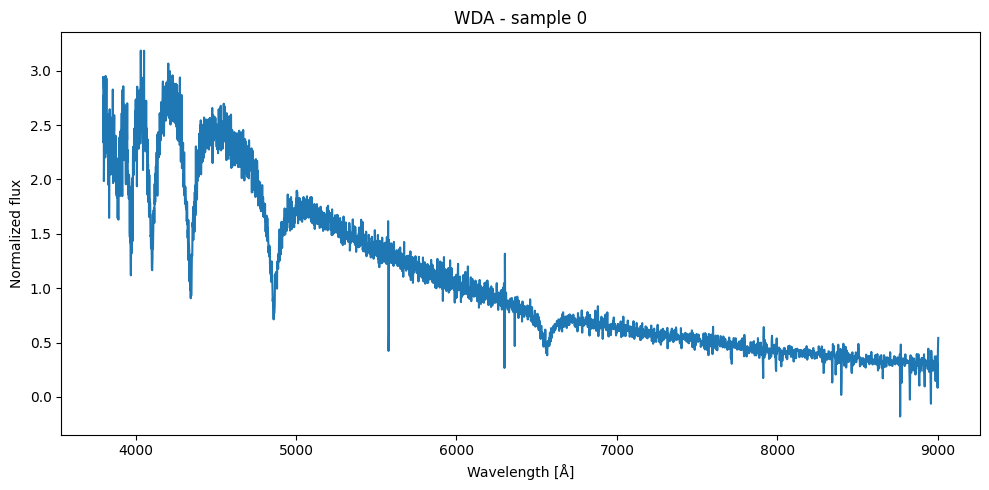

In [33]:
W_wda, X_wda_spec, X_wda_input, df_wda_DRAC = load_class_spectra_DRACULA_with_wavelength(
    "WDA",
    n_samples=1100,
    random_state=42
)

sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(W_wda[sample_idx], X_wda_spec[sample_idx])
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized flux")
plt.title(f"WDA - sample {sample_idx}")
plt.tight_layout()
plt.show()

# Experimentos WDA 

In [34]:
# Datos para DRACULA
X_wda_spec, X_wda_input, df_wda_DRAC = load_class_spectra_DRACULA("WDA", n_samples=1100, random_state=42)
flatten_wda_DRAC, dense_wda_DRAC, dense1_wda_DRAC, dense2_wda_DRAC = extract_layer_features(X_wda_input)
repr_wda_32 = reduce_all_to_32(flatten_wda_DRAC, dense_wda_DRAC, dense1_wda_DRAC, dense2_wda_DRAC)

WDA: disponibles con match a .dat = 13723
WDA: espectros válidos finales = 1100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
flatten: (1100, 208)
dense: (1100, 128)
dense_1: (1100, 64)
dense_2: (1100, 32)
flatten_32: (1100, 32)
dense_32: (1100, 32)
dense1_32: (1100, 32)
dense2_32: (1100, 32)


### Ejecutar funciones para obtener las etiquetas en todas las capas

In [35]:
# =========================================================
# WDA - OBTENER LABELS DE TODAS LAS CAPAS
# =========================================================

# -------- flatten --------
labels_flatten_km, labels_flatten_sp, labels_flatten_db = get_clustering_labels(
    repr_wda_32["flatten"],
    kmeans_k=3,
    spectral_k=3,
    dbscan_eps=1.5,
    dbscan_min_samples=10,
    random_state=42
)

save_cluster_labels(cluster_labels_all, "WDA", "flatten", "kmeans", labels_flatten_km)
save_cluster_labels(cluster_labels_all, "WDA", "flatten", "spectral", labels_flatten_sp)
save_cluster_labels(cluster_labels_all, "WDA", "flatten", "dbscan", labels_flatten_db)


# -------- dense --------
labels_dense_km, labels_dense_sp, labels_dense_db = get_clustering_labels(
    repr_wda_32["dense"],
    kmeans_k=3,
    spectral_k=3,
    dbscan_eps=1.5,
    dbscan_min_samples=10,
    random_state=42
)

save_cluster_labels(cluster_labels_all, "WDA", "dense", "kmeans", labels_dense_km)
save_cluster_labels(cluster_labels_all, "WDA", "dense", "spectral", labels_dense_sp)
save_cluster_labels(cluster_labels_all, "WDA", "dense", "dbscan", labels_dense_db)


# -------- dense_1 --------
labels_dense1_km, labels_dense1_sp, labels_dense1_db = get_clustering_labels(
    repr_wda_32["dense_1"],
    kmeans_k=3,
    spectral_k=3,
    dbscan_eps=1.5,
    dbscan_min_samples=10,
    random_state=42
)

save_cluster_labels(cluster_labels_all, "WDA", "dense_1", "kmeans", labels_dense1_km)
save_cluster_labels(cluster_labels_all, "WDA", "dense_1", "spectral", labels_dense1_sp)
save_cluster_labels(cluster_labels_all, "WDA", "dense_1", "dbscan", labels_dense1_db)


# -------- dense_2 --------
labels_dense2_km, labels_dense2_sp, labels_dense2_db = get_clustering_labels(
    repr_wda_32["dense_2"],
    kmeans_k=3,
    spectral_k=3,
    dbscan_eps=1.5,
    dbscan_min_samples=10,
    random_state=42
)

save_cluster_labels(cluster_labels_all, "WDA", "dense_2", "kmeans", labels_dense2_km)
save_cluster_labels(cluster_labels_all, "WDA", "dense_2", "spectral", labels_dense2_sp)
save_cluster_labels(cluster_labels_all, "WDA", "dense_2", "dbscan", labels_dense2_db)


print("Labels WDA guardados correctamente.")
print(cluster_labels_all["WDA"].keys())

Labels WDA guardados correctamente.
dict_keys(['flatten', 'dense', 'dense_1', 'dense_2'])


## Gráficos t-SNE y PCA -> para Spectral Clustering y DBSCAN 

### Resultados capa flatten, con Spectral Clustering + tSNE y PCA


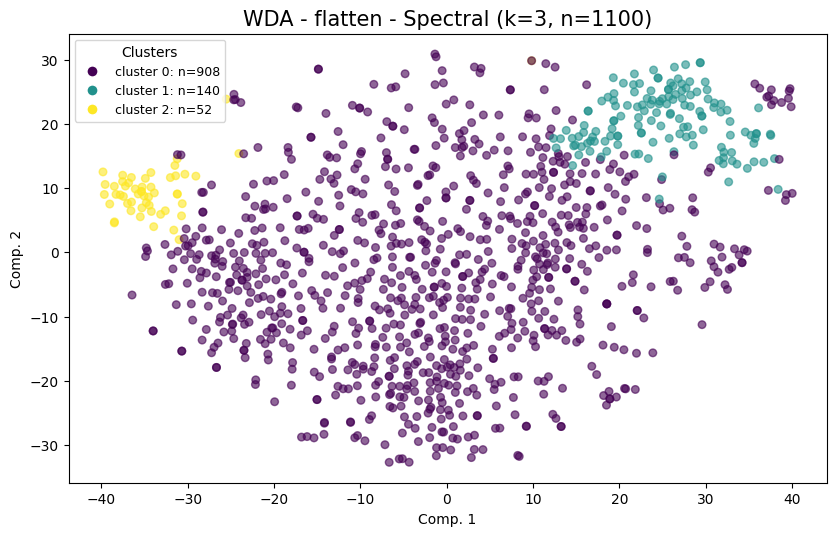

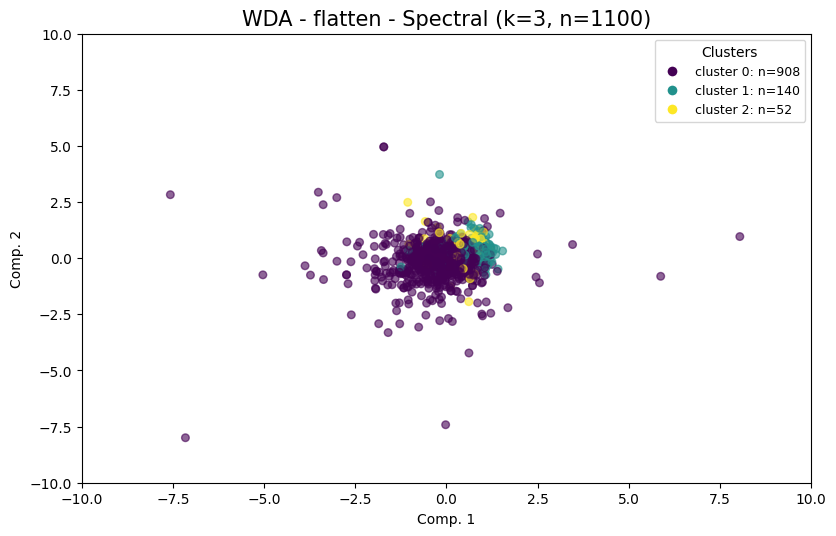

{'spectral': array([0, 1, 0, ..., 0, 0, 0])}

In [54]:
res_k3=cluster_plot_Spect(
            repr_wda_32["flatten"],
            "WDA",
            "flatten",
            spectral_k=3,
            vis_method="tsne"
        )
labels_flatten_k3 = res_k3["spectral"]
cluster_plot_Spect(
            repr_wda_32["flatten"],
            "WDA",
            "flatten",
            spectral_k=3, 
            vis_method="pca",
            xlim=(-10,10), ylim=(-10,10)
        )

#### Spectral Clustering k = 4

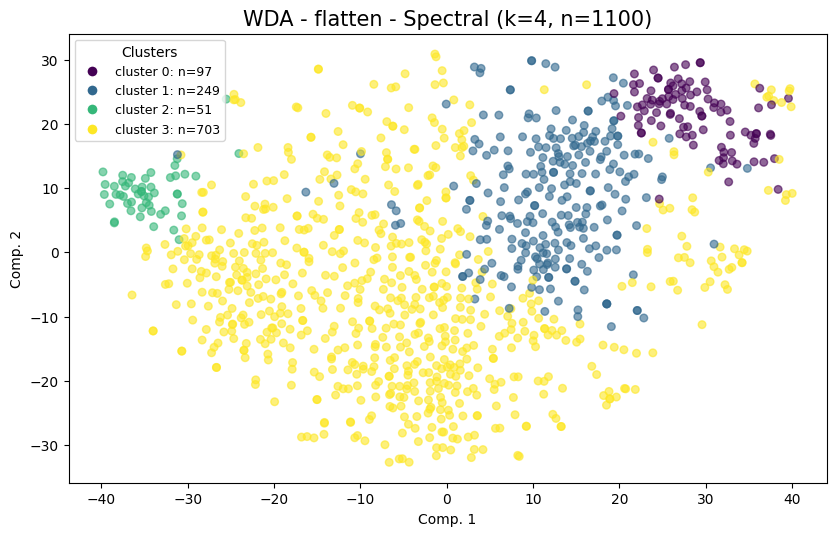

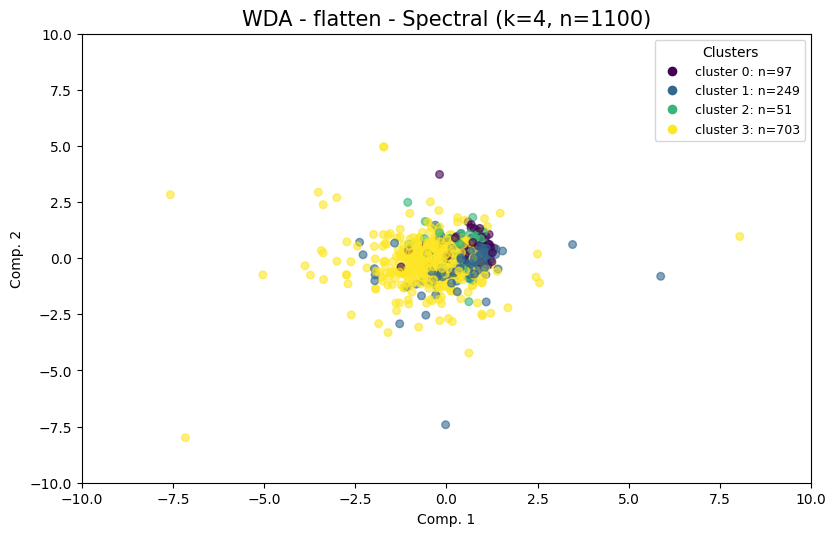

{'spectral': array([3, 1, 3, ..., 3, 3, 3])}

In [55]:
res_k4 = cluster_plot_Spect(
            repr_wda_32["flatten"],
            "WDA",
            "flatten",
            spectral_k=4,
            vis_method="tsne"
        )
labels_flatten_k4 = res_k4["spectral"]
cluster_plot_Spect(
            repr_wda_32["flatten"],
            "WDA",
            "flatten",
            spectral_k=4, 
            vis_method="pca",
            xlim=(-10,10), ylim=(-10,10)
        )

#### Spectral Clustering k = 2

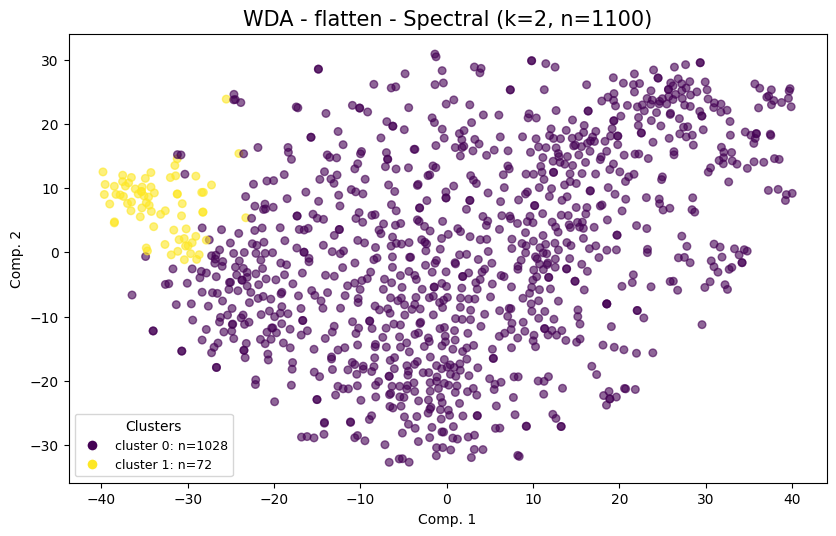

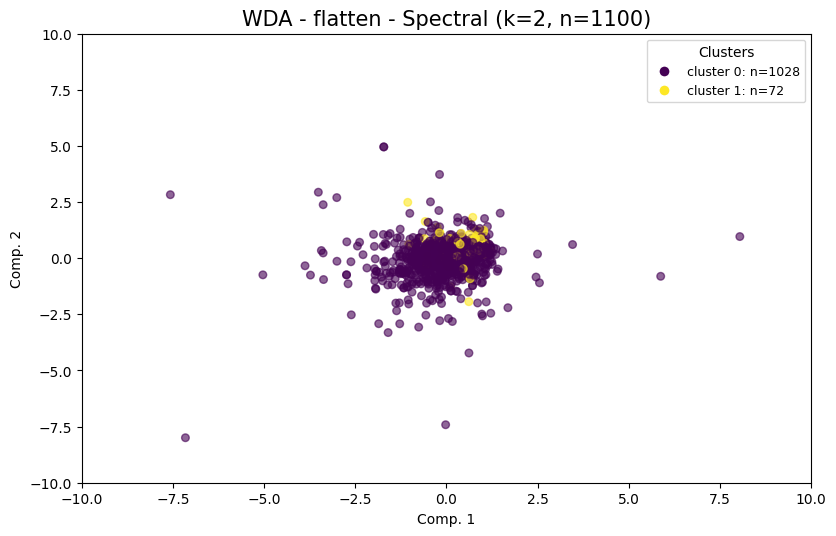

{'spectral': array([0, 0, 0, ..., 0, 0, 0])}

In [53]:
res_k2 = cluster_plot_Spect(
            repr_wda_32["flatten"],
            "WDA",
            "flatten",
            spectral_k=2,
            vis_method="tsne"
        )
        
labels_flatten_k2 = res_k2["spectral"]

cluster_plot_Spect(
            repr_wda_32["flatten"],
            "WDA",
            "flatten",
            spectral_k=2, 
            vis_method="pca",
            xlim=(-10,10), ylim=(-10,10)
        )

### Análisis de migración de clústeres — Capa Flatten, Spectral Clustering

Se compara cómo los datos migran entre las configuraciones k=2, k=3 y k=4.  
La **matriz de contingencia** cuenta cuántas muestras compartidas hay entre cada par de clústeres.  
Las filas/columnas se reordenan con el **algoritmo húngaro** (`linear_sum_assignment`) para maximizar la diagonal y facilitar la lectura.  
Comparaciones realizadas: k=2 → k=3, k=3 → k=4, y k=2 → k=4.

Generando gráficos y extrayendo etiquetas reales...

=== COMPROBACIÓN DE COHERENCIA ===
Muestras en variables — k=2: [1028   72]
Muestras en variables — k=3: [908 140  52]
Muestras en variables — k=4: [ 97 249  51 703]



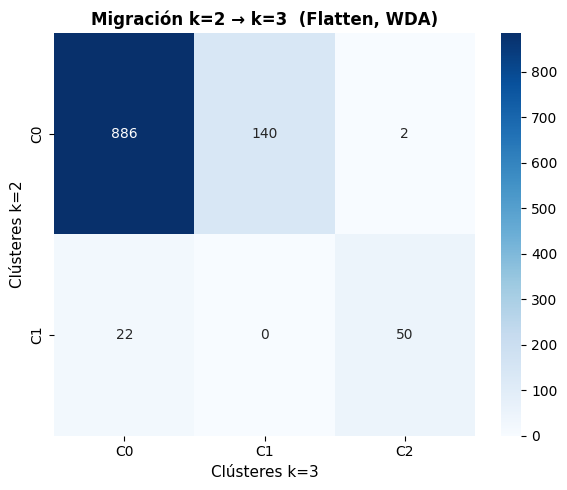

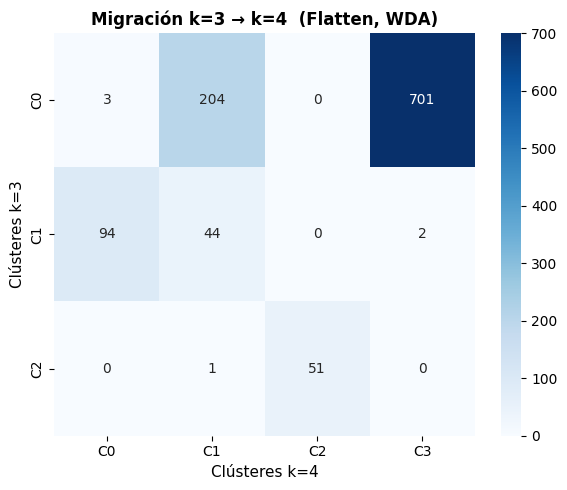

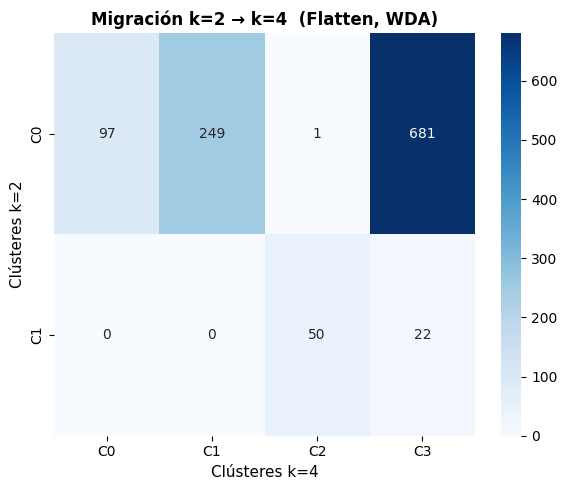

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.cluster import contingency_matrix

# ── 1. FUNCIÓN PARA LA MATRIZ DE MIGRACIÓN REAL (SIN REORDENAMIENTOS) ──────────
def plot_migration_matrix(labels_a, labels_b, ka, kb, title=None, figsize=(6, 5)):
    """
    Genera un heatmap directo y fiel entre dos asignaciones de clústeres.
    """
    cm = contingency_matrix(labels_a, labels_b)
    
    rows_labels = [f'C{i}' for i in range(cm.shape[0])]
    cols_labels = [f'C{j}' for j in range(cm.shape[1])]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=cols_labels,
        yticklabels=rows_labels,
        ax=ax
    )
    ax.set_xlabel(f'Clústeres k={kb}', fontsize=11)
    ax.set_ylabel(f'Clústeres k={ka}', fontsize=11)
    _title = title if title else f'Migración k={ka} → k={kb}  (Flatten, WDA)'
    ax.set_title(_title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── 2. OBTENER LAS LABELS EXACTAS USANDO TU PROPIA FUNCIÓN ────────────────────
print("Generando gráficos y extrayendo etiquetas reales...")


# ── 3. COMPROBACIÓN ESTRICTA EN CONSOLA ───────────────────────────────────────
print("\n=== COMPROBACIÓN DE COHERENCIA ===")
print(f'Muestras en variables — k=2: {np.bincount(labels_flatten_k2)}')
print(f'Muestras en variables — k=3: {np.bincount(labels_flatten_k3)}')
print(f'Muestras en variables — k=4: {np.bincount(labels_flatten_k4)}')
print("===================================\n")


# ── 4. GRAFICAR MATRICES DE MIGRACIÓN COHERENTES ──────────────────────────────
# Ahora las filas y columnas sumarán EXACTAMENTE lo que dicen tus gráficos
plot_migration_matrix(labels_flatten_k2, labels_flatten_k3, ka=2, kb=3)
plot_migration_matrix(labels_flatten_k3, labels_flatten_k4, ka=3, kb=4)
plot_migration_matrix(labels_flatten_k2, labels_flatten_k4, ka=2, kb=4)

Observación Matriz 1 (k=2 -> k=3): C0 y C1 de k=3 forman C0 de C0, con algunas excepciones de C2 de k=3
Observación Matriz 2 (k=3 -> k=4):


### Resultados capa dense_1 con Spectral Clustering + tSNE y PCA

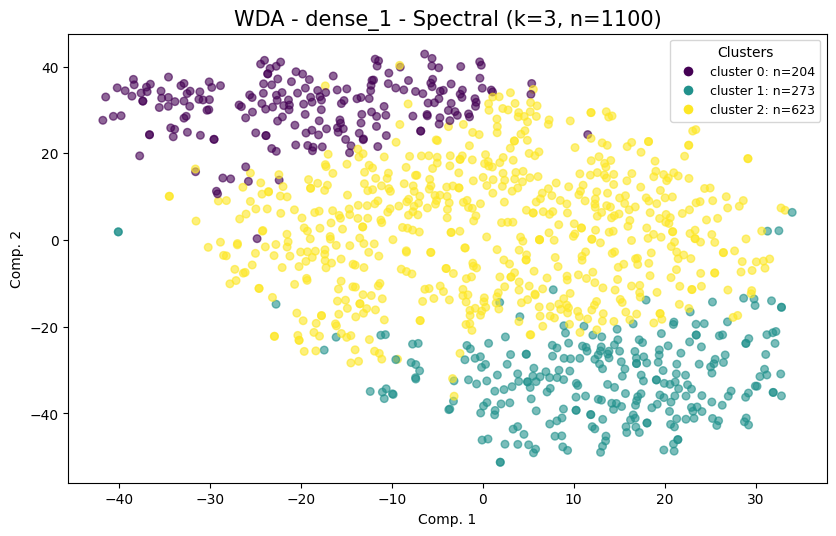

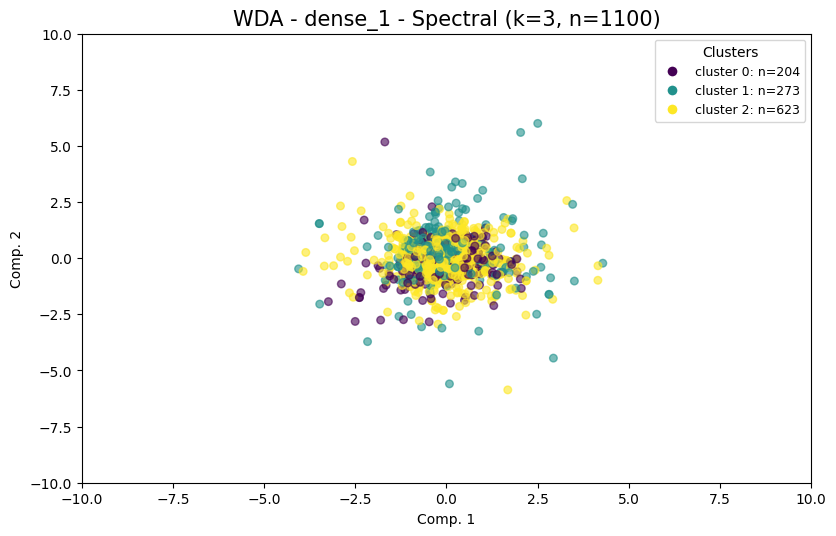

{'spectral': array([0, 1, 2, ..., 1, 2, 2])}

In [38]:
cluster_plot_Spect(
            repr_wda_32["dense_1"],
            "WDA",
            "dense_1",
            spectral_k=3,
            vis_method="tsne"
        )

cluster_plot_Spect(
            repr_wda_32["dense_1"],
            "WDA",
            "dense_1",
            spectral_k=3, 
            vis_method="pca",
            xlim=(-10,10), ylim=(-10,10)
        )

### Resultados capa dense_2 con Spectral Clustering + tSNE y PCA

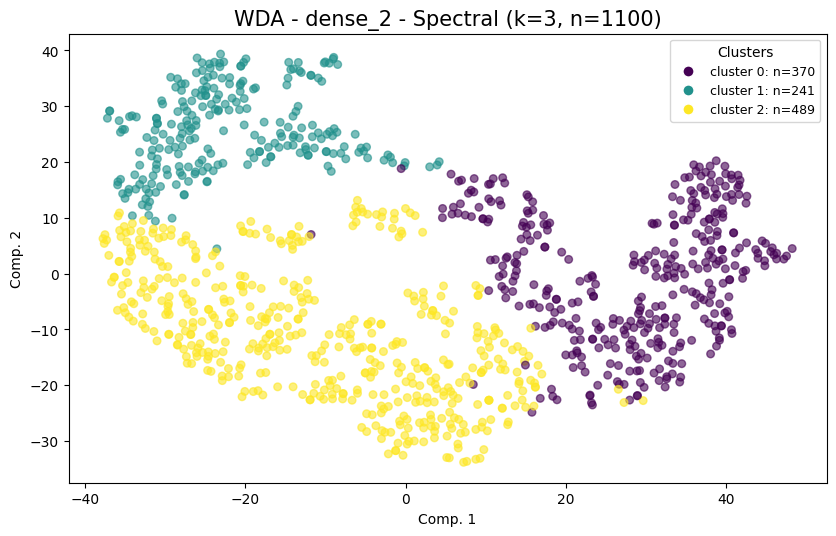

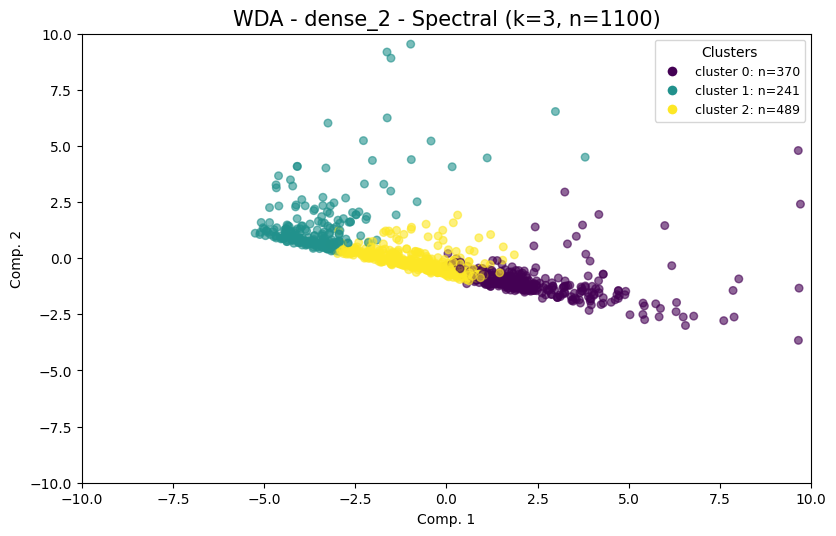

{'spectral': array([0, 1, 2, ..., 2, 0, 2])}

In [39]:
cluster_plot_Spect(
            repr_wda_32["dense_2"],
            "WDA",
            "dense_2",
            spectral_k=3,
            vis_method="tsne"
        )

cluster_plot_Spect(
            repr_wda_32["dense_2"],
            "WDA",
            "dense_2",
            spectral_k=3, 
            vis_method="pca",
            xlim=(-10,10), ylim=(-10,10)
        )

### Graficar resultados en capa Flatten con Spectral 
Se grafican los espectros de los grupos generados con Spectral Clustering (superpuestos), el espectro promedio de todos los datos de WDA y el promedio de cada grupo

C:\Users\javip\AppData\Local\Temp\ipykernel_15072\3173161435.py:119: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


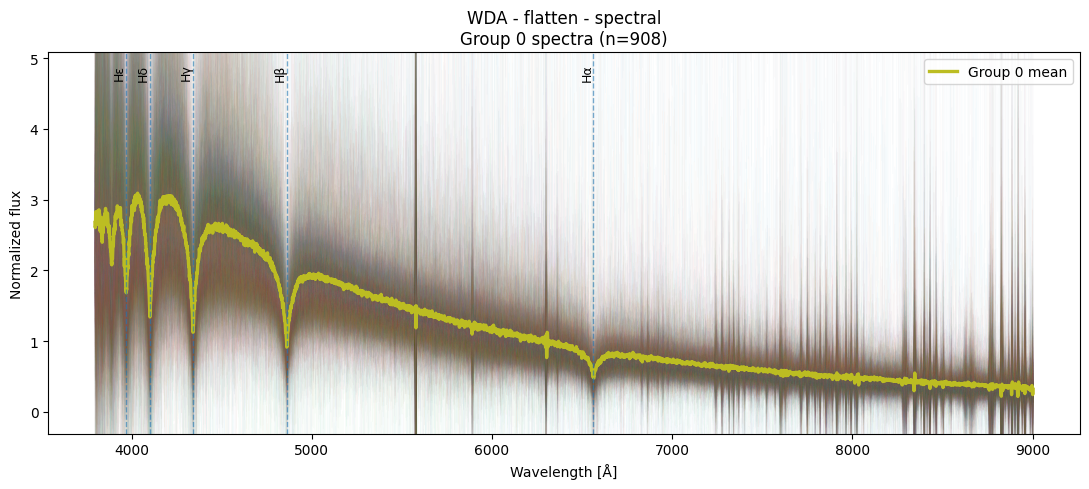

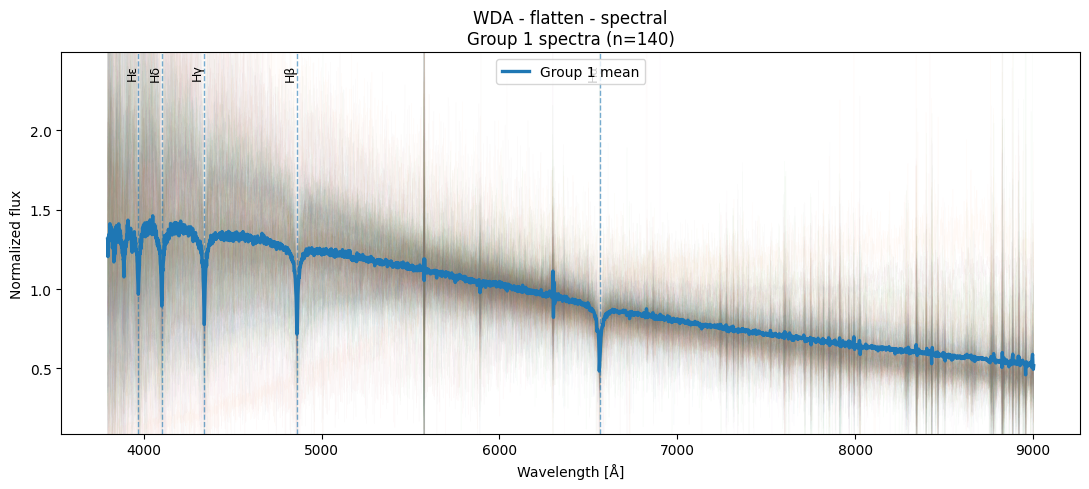

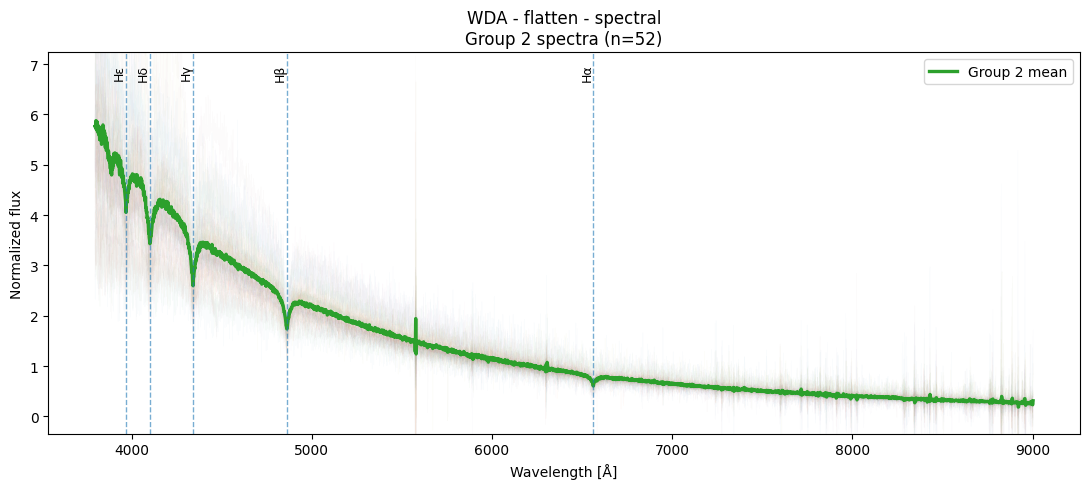

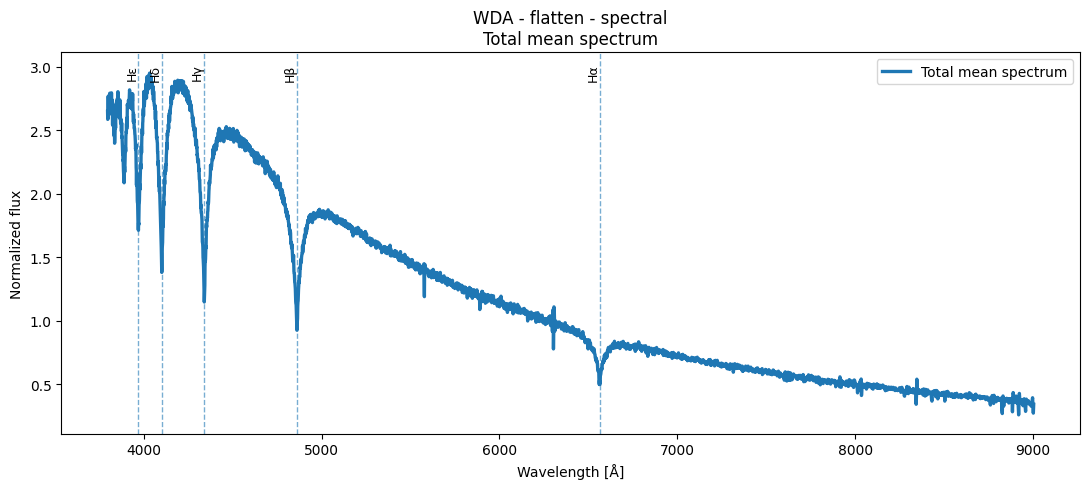

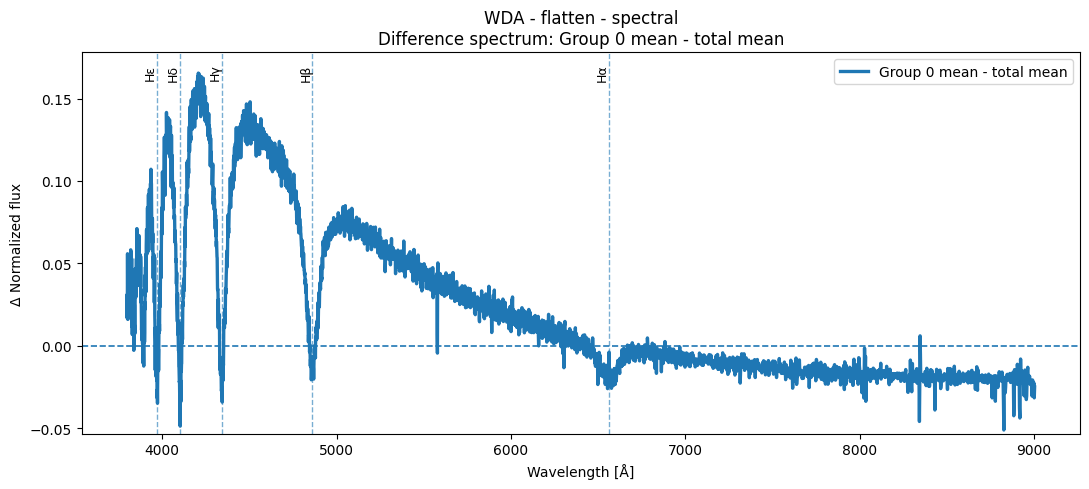

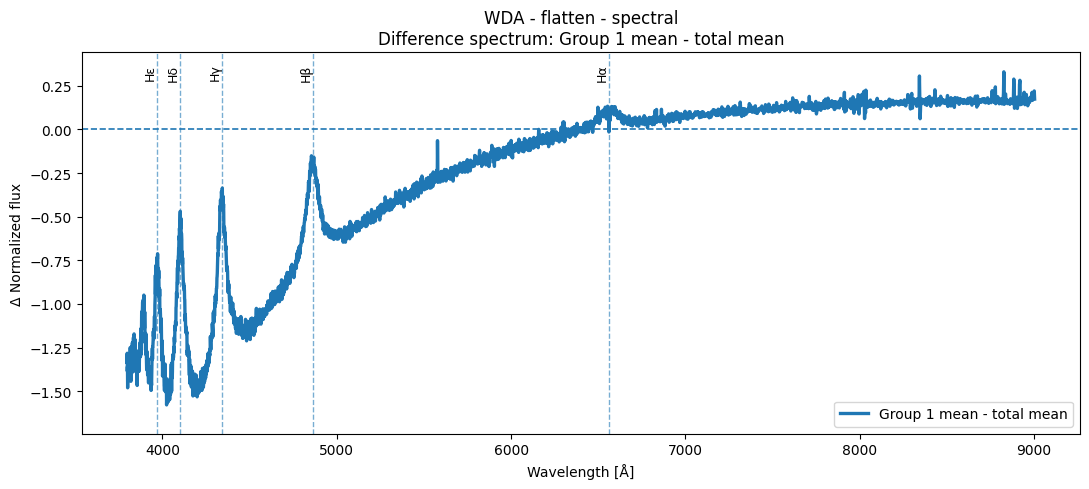

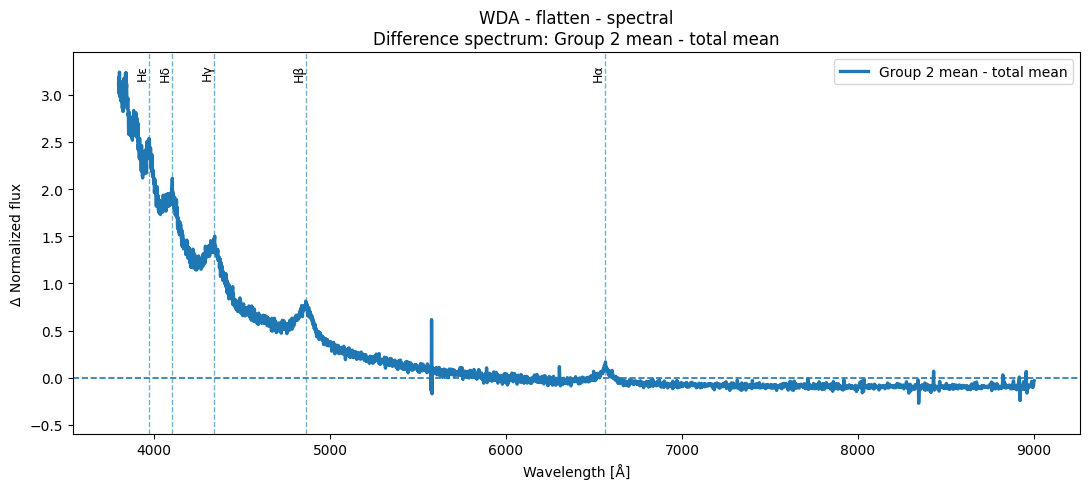

In [40]:
labels_wda_flatten_spectral = cluster_labels_all["WDA"]["flatten"]["spectral"]

if W_wda.ndim == 2:
    wavelength_wda = W_wda[0]
else:
    wavelength_wda = W_wda

results_7fig_wda_flatten_spectral = plot_7_figures_wda_flatten_spectral(
    spectra_2d=X_wda_spec,
    labels=labels_wda_flatten_spectral,
    wavelength=wavelength_wda,
    class_name="WDA",
    layer_name="flatten",
    method_name="spectral",
    alpha_group=0.02,       # más bajo para evitar "mancha"
    linewidth_group=0.5,    # líneas más finas
    linewidth_mean=2.4,
    figsize=(11, 5),
    mark_balmer=True,
    robust_ylim=True
)

### Gráfico de el promedio de cada grupo generado por Spectral Clustering en Flatten + el promedio de todos los datos

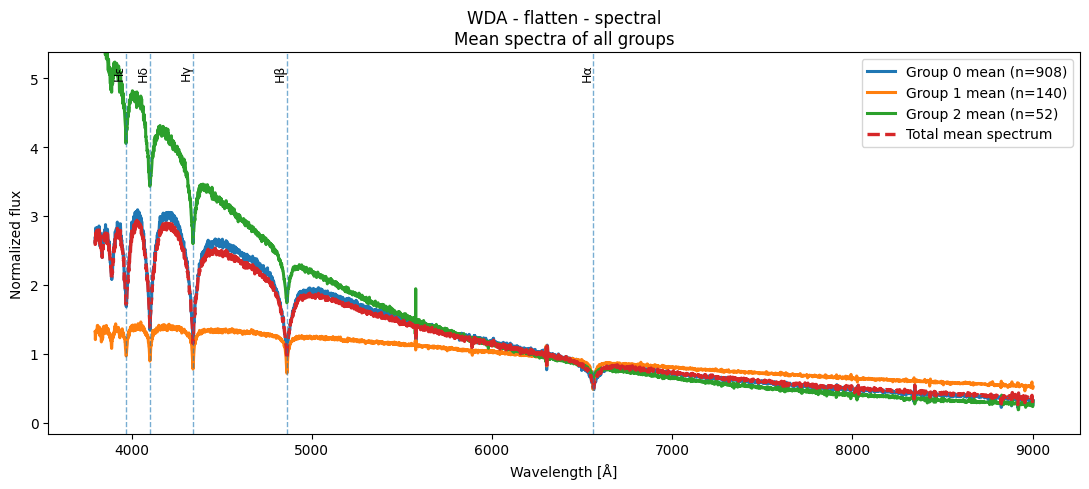

In [41]:
plot_cluster_means_together_from_7fig_results(
    results_7fig=results_7fig_wda_flatten_spectral,
    labels=labels_wda_flatten_spectral,
    wavelength=wavelength_wda,
    class_name="WDA",
    layer_name="flatten",
    method_name="spectral",
    include_total_mean=True,
    mark_balmer=True,
    robust_ylim=True,
    figsize=(11, 5)
)

In [42]:
# uso de interact
# --- Dropdowns ---
layer_dropdown = widgets.Dropdown(
    options=["flatten", "dense", "dense_1", "dense_2"],
    value="dense_1",
    description="Capa:",
)

method_dropdown = widgets.Dropdown(
    options=["kmeans", "spectral", "dbscan"],
    value="spectral",
    description="Metodo:",
)

# --- Funcion wrapper para interact ---
def interactive_plot(layer_name, method_name):
    plot_cluster_spectra(
        layer_name=layer_name,
        method_name=method_name,
        class_name="WDA",
        spectra_2d=X_wda_spec,
        wavelength_2d=W_wda,
        cluster_labels_dict=cluster_labels_all["WDA"],
    )

# --- Lanzar interact ---
interact(
    interactive_plot,
    layer_name=layer_dropdown,
    method_name=method_dropdown,
)


interactive(children=(Dropdown(description='Capa:', index=2, options=('flatten', 'dense', 'dense_1', 'dense_2'…

<function __main__.interactive_plot(layer_name, method_name)>

# Experimentos WDB

In [43]:
# Experimento WDB
X_wdb, df_wdb = load_class_spectra("WDB", n_samples=1100, random_state=42)

flatten_wdb, dense_wdb, dense1_wdb, dense2_wdb = extract_layer_features(X_wdb)

repr_wdb_32 = reduce_all_to_32(flatten_wdb, dense_wdb, dense1_wdb, dense2_wdb)

WDB: disponibles con match a .dat = 1184
WDB: espectros válidos finales = 1099
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
flatten: (1099, 208)
dense: (1099, 128)
dense_1: (1099, 64)
dense_2: (1099, 32)
flatten_32: (1099, 32)
dense_32: (1099, 32)
dense1_32: (1099, 32)
dense2_32: (1099, 32)


### Evaluación K

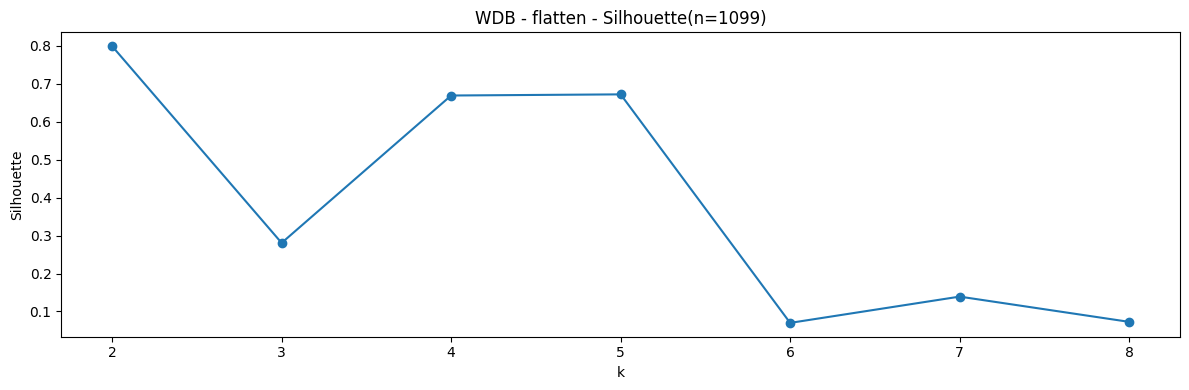

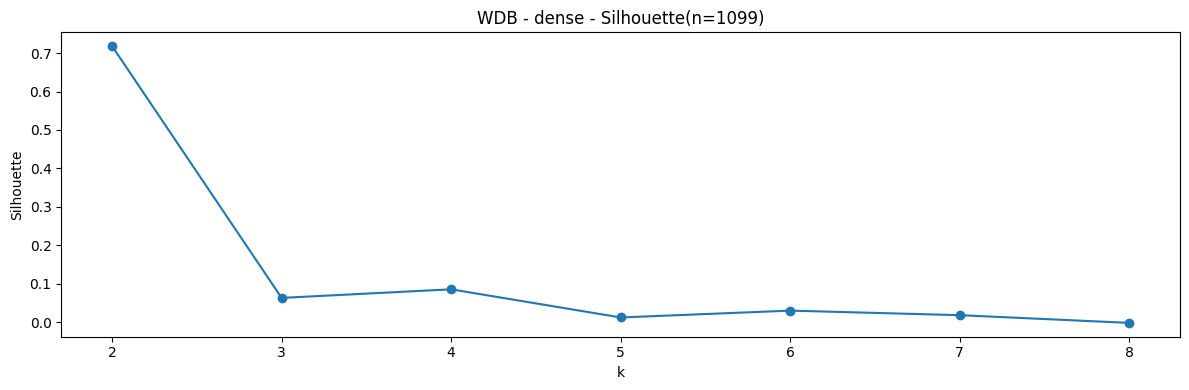

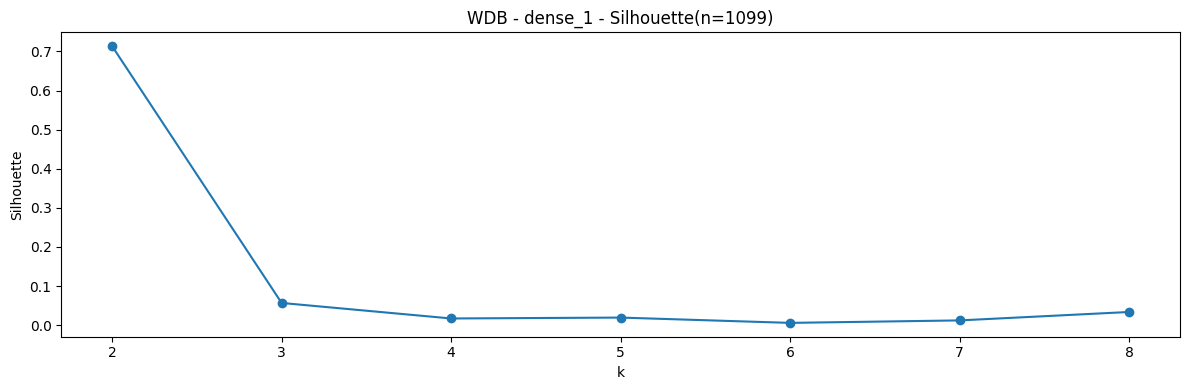

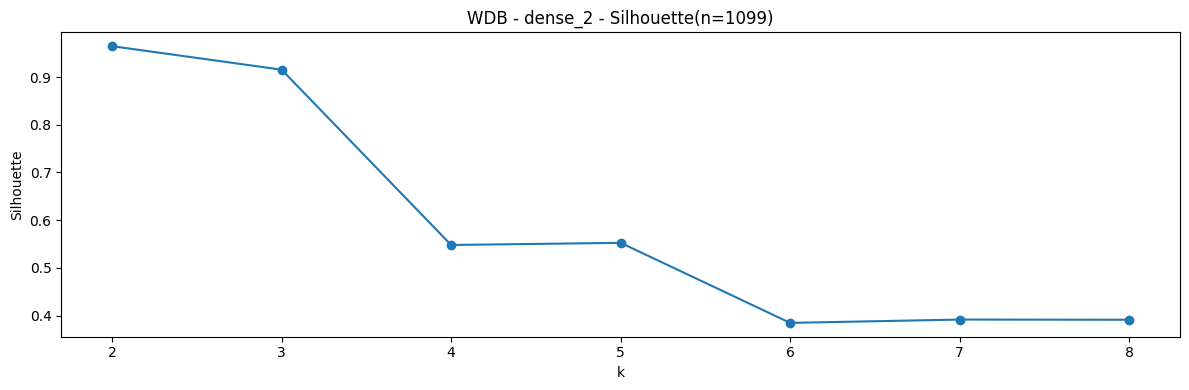

In [44]:
evaluate_kmeans_k(repr_wdb_32["flatten"], "WDB", "flatten")
evaluate_kmeans_k(repr_wdb_32["dense"], "WDB", "dense")
evaluate_kmeans_k(repr_wdb_32["dense_1"], "WDB", "dense_1")
evaluate_kmeans_k(repr_wdb_32["dense_2"], "WDB", "dense_2")

### Gráficos t-SNE y PCA + clustering